# ECS7005P — Google Colab Code File
### Risk and Decision Making for Big Data and AI — 2025/2026

**How to use this notebook:**
1. Run cells **in order** from top to bottom — do not skip cells
2. Upload your three CSV files via the **Files panel** (📁 folder icon, left sidebar)
3. After each cell marked `[SCREENSHOT]`, take a screenshot of the cell AND its output
4. Insert each screenshot into the Word document at the location described in the comment

> **Tip:** Press `Shift + Enter` to run a cell and move to the next one automatically.

---
## Setup — Run First (Every Session)

In [ ]:
# ── CELL 1 — Install packages ─────────────────────────────────────────────
# Run this cell first, every time you open the notebook.
# Wait for the output to say "All packages ready." before continuing.
# NO SCREENSHOT NEEDED for this cell.

!pip install pyagrum -q

import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.causal as csl
import pandas as pd
import matplotlib.pyplot as plt

print("All packages ready.")

All packages ready.


In [ ]:
# ── CELL 2 — Upload CSV files ─────────────────────────────────────────────
# Before running this cell:
#   1. Click the FOLDER icon on the left sidebar
#   2. Click the UPLOAD button (paper + up arrow icon)
#   3. Upload all three files:
#        - student_bn_dataset_50.csv
#        - song_success_20.csv
#        - shift_screen_fatigue_1200.csv
# NO SCREENSHOT NEEDED for this cell.

import os
needed = ['student_bn_dataset_50.csv', 'song_success_20.csv', 'shift_screen_fatigue_1200.csv']
for f in needed:
    status = "FOUND" if os.path.exists(f) else "MISSING — please upload"
    print(f"  {f}: {status}")

  student_bn_dataset_50.csv: FOUND
  song_success_20.csv: FOUND
  shift_screen_fatigue_1200.csv: FOUND


---
## Question 1 — Bayesian Networks for Student Performance

BN structure created successfully.
Nodes: ['Intelligence', 'Motivation', 'StudyHours', 'Sleep', 'Stress', 'Grade']
Arcs:  [(1, 2), (3, 4), (4, 5), (0, 2), (2, 5), (3, 5)]



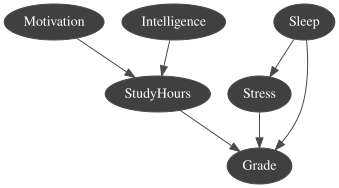

In [ ]:
# ── CELL 3 — Q1(a): Build the Bayesian Network DAG ──────────────────────
# PURPOSE : Creates the BN structure from the domain knowledge story.
# OUTPUT  : A visual diagram of the Bayesian network.
#
# [SCREENSHOT — Q1a]
#   Screenshot 1 : this code cell
#   Screenshot 2 : the BN diagram that appears below
#   → Insert BOTH into the Word doc under:
#     "Part (a) — Bayesian Network DAG"
#     (where it says "[Screenshot of BN DAG to be inserted here]")

bn = gum.BayesNet('StudentPerformance')

# Add all six binary variables
bn.add(gum.LabelizedVariable('Intelligence', 'Intelligence', ['low', 'high']))
bn.add(gum.LabelizedVariable('Motivation',   'Motivation',   ['low', 'high']))
bn.add(gum.LabelizedVariable('StudyHours',   'StudyHours',   ['low', 'high']))
bn.add(gum.LabelizedVariable('Sleep',        'Sleep',        ['poor', 'good']))
bn.add(gum.LabelizedVariable('Stress',       'Stress',       ['low', 'high']))
bn.add(gum.LabelizedVariable('Grade',        'Grade',        ['poor', 'good']))

# Add directed arcs based on domain knowledge
bn.addArc('Intelligence', 'StudyHours')   # higher intelligence  → more study
bn.addArc('Motivation',   'StudyHours')   # higher motivation    → more study
bn.addArc('Sleep',        'Stress')       # poor sleep           → higher stress
bn.addArc('Sleep',        'Grade')        # poor sleep           → directly harms grade
bn.addArc('StudyHours',   'Grade')        # more study           → better grade
bn.addArc('Stress',       'Grade')        # high stress          → worse grade

print("BN structure created successfully.")
print("Nodes:", [bn.variable(n).name() for n in bn.nodes()])
print("Arcs: ", list(bn.arcs()))
print()
gnb.showBN(bn)

Dataset loaded: 50 rows, 6 columns
  Intelligence Motivation StudyHours Sleep Stress Grade
0          low       high       high  good    low  good
1          low       high       high  good   high  good
2         high        low       high  good    low  good
3         high        low        low  good   high  poor
4         high       high        low  poor    low  poor 

Parameters learnt successfully.

CPT for: Intelligence

  Intelligence     |
low      |high     |
---------|---------|
 0.3824  | 0.6176  |


CPT for: Motivation

  Motivation       |
low      |high     |
---------|---------|
 0.5980  | 0.4020  |


CPT for: StudyHours

             ||  StudyHours       |
Intell|Motiva||low      |high     |
------|------||---------|---------|
low   |low   || 0.7500  | 0.2500  |
high  |low   || 0.4167  | 0.5833  |
low   |high  || 0.3571  | 0.6429  |
high  |high  || 0.3000  | 0.7000  |


CPT for: Sleep

  Sleep            |
poor     |good     |
---------|---------|
 0.2451  | 0.7549  |


C

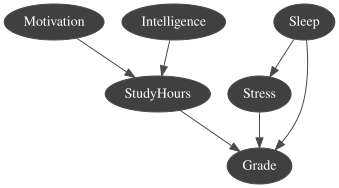

In [ ]:
# ── CELL 4 — Q1(b): Learn CPTs from data ────────────────────────────────
# PURPOSE : Trains conditional probability tables from the 50-row dataset.
# OUTPUT  : All six CPT tables printed, followed by the trained BN diagram.
#
# [SCREENSHOT — Q1b]
#   Screenshot 1 : this code cell + the printed CPT output
#   Screenshot 2 : the BN diagram with parameters
#   → Insert BOTH into the Word doc under:
#     "Part (b) — Learning Parameters from Data"
#     (where it says "[Screenshots of CPTs and trained BN to be inserted here]")

df = pd.read_csv('student_bn_dataset_50.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.head(), "\n")

# Fix the structure (from Cell 3), learn only the probability values
learner = gum.BNLearner(df, bn)
learner.useSmoothingPrior(0.5)   # Laplace smoothing avoids zero-probabilities on small data

bn_trained = learner.learnParameters(bn.dag())
print("Parameters learnt successfully.\n")

# Print every CPT
for node_id in bn_trained.nodes():
    name = bn_trained.variable(node_id).name()
    print(f"{'='*50}")
    print(f"CPT for: {name}")
    print(f"{'='*50}")
    print(bn_trained.cpt(node_id))
    print()

gnb.showBN(bn_trained)

In [ ]:
# ── CELL 5 — Q1(c): Berkson's Paradox / Explaining Away ────────────────
# PURPOSE : Shows that Intelligence and Motivation are marginally independent,
#           but become DEPENDENT when we condition on StudyHours (a collider).
#           This is Berkson's paradox — the core concept behind this question.
# OUTPUT  : Probability values demonstrating the dependency change.
#
# [SCREENSHOT — Q1c]
#   Screenshot 1 : this code cell
#   Screenshot 2 : the printed probability output
#   → Insert BOTH into the Word doc under:
#     "Part (c) — Explaining the Intelligence–Motivation Dependency"
#     (where it says "[Screenshot of code and output to be inserted here]")

ie = gum.LazyPropagation(bn_trained)

# Step 1: Prior — no evidence at all
ie.makeInference()
prior = ie.posterior('Intelligence')[{'Intelligence': 'high'}]
print(f"1. P(Intelligence=high)  [no evidence]  = {prior:.4f}")
print()

# Step 2: Condition on Motivation only — Intelligence and Motivation have NO arc,
# so this should NOT change our belief about Intelligence
ie.setEvidence({'Motivation': 'high'})
ie.makeInference()
p2 = ie.posterior('Intelligence')[{'Intelligence': 'high'}]
print(f"2. P(Intelligence=high | Motivation=high)  = {p2:.4f}")
print("   → Same as Step 1 (no arc exists between them; d-separated)")
print()

# Step 3: Now also condition on StudyHours=high (the collider)
# This OPENS the path: Intelligence → StudyHours ← Motivation
ie.setEvidence({'Motivation': 'high', 'StudyHours': 'high'})
ie.makeInference()
p3 = ie.posterior('Intelligence')[{'Intelligence': 'high'}]
print(f"3. P(Intelligence=high | Motivation=high, StudyHours=high)  = {p3:.4f}")
print("   → DIFFERENT from Step 2! Conditioning on the collider opens the path.")
print()

# Step 4: Key finding — if we see StudyHours=high AND Intelligence=low,
# we infer high Motivation is more probable (the 'explaining away' effect)
ie.setEvidence({'StudyHours': 'high', 'Intelligence': 'low'})
ie.makeInference()
p4 = ie.posterior('Motivation')[{'Motivation': 'high'}]
print(f"4. P(Motivation=high | StudyHours=high, Intelligence=low)  = {p4:.4f}")
print("   → Among high-study, low-intelligence students, high motivation is inferred.")
print()
print("CONCLUSION: StudyHours is a COLLIDER on the path Intelligence→StudyHours←Motivation.")
print("Conditioning on it opens the path (Berkson's Paradox).")
print("This is why low intelligence makes someone more 'likely to be motivated' once we")
print("know they study a lot — the model explains away the surprising study behaviour.")

1. P(Intelligence=high)  [no evidence]  = 0.6176

2. P(Intelligence=high | Motivation=high)  = 0.6176
   → Same as Step 1 (no arc exists between them; d-separated)

3. P(Intelligence=high | Motivation=high, StudyHours=high)  = 0.6375
   → DIFFERENT from Step 2! Conditioning on the collider opens the path.

4. P(Motivation=high | StudyHours=high, Intelligence=low)  = 0.6335
   → Among high-study, low-intelligence students, high motivation is inferred.

CONCLUSION: StudyHours is a COLLIDER on the path Intelligence→StudyHours←Motivation.
Conditioning on it opens the path (Berkson's Paradox).
This is why low intelligence makes someone more 'likely to be motivated' once we
know they study a lot — the model explains away the surprising study behaviour.


In [ ]:
# ── CELL 6 — Q1(d): Alice's probability of good grades ──────────────────
# PURPOSE : Computes P(Grade=good) given Alice's profile:
#           Intelligence=high, Motivation=low, Sleep=poor
# OUTPUT  : Posterior probability distribution over Grade.
#
# [SCREENSHOT — Q1d]
#   Screenshot 1 : this code cell
#   Screenshot 2 : the printed probability output
#   → Insert BOTH into the Word doc under:
#     "Part (d) — Alice's Probability of Good Grades"
#     (where it says "[Screenshot of code and output to be inserted here]")

ie = gum.LazyPropagation(bn_trained)

# Alice's observed profile
ie.setEvidence({
    'Intelligence': 'high',   # Alice is intelligent
    'Motivation':   'low',    # but has low motivation
    'Sleep':        'poor'    # and has poor sleep
})

ie.makeInference()

print("Alice's profile: Intelligence=high, Motivation=low, Sleep=poor")
print()
print("Posterior distribution over Grade:")
print(ie.posterior('Grade'))
print()
p_good = ie.posterior('Grade')[{'Grade': 'good'}]
p_poor = ie.posterior('Grade')[{'Grade': 'poor'}]
print(f"P(Grade=good | Alice) = {p_good:.4f}  ({p_good*100:.1f}%)")
print(f"P(Grade=poor | Alice) = {p_poor:.4f}  ({p_poor*100:.1f}%)")
print()
print("INTERPRETATION: Despite high intelligence, Alice's low motivation means")
print("fewer study hours, and poor sleep raises stress and directly harms grades.")
print("Multiple risk factors combine to produce this probability.")

Alice's profile: Intelligence=high, Motivation=low, Sleep=poor

Posterior distribution over Grade:

  Grade            |
poor     |good     |
---------|---------|
 0.5312  | 0.4688  |


P(Grade=good | Alice) = 0.4688  (46.9%)
P(Grade=poor | Alice) = 0.5312  (53.1%)

INTERPRETATION: Despite high intelligence, Alice's low motivation means
fewer study hours, and poor sleep raises stress and directly harms grades.
Multiple risk factors combine to produce this probability.


In [ ]:
# ── CELL 7 — Q1(e): Counterfactual — Motivation vs Sleep ────────────────
# PURPOSE : Uses do-calculus to compare two hypothetical interventions for Alice:
#           (1) What if Motivation had been HIGH instead of low?
#           (2) What if Sleep had been GOOD instead of poor?
#           We compare which change would most improve P(Grade=good).
# OUTPUT  : Probabilities under each intervention with comparison.
#
# [SCREENSHOT — Q1e]
#   Screenshot 1 : this code cell
#   Screenshot 2 : the printed output comparing the two interventions
#   → Insert BOTH into the Word doc under:
#     "Part (e) — Counterfactual Analysis: Motivation vs. Sleep"
#     (where it says "[Screenshot of code and output to be inserted here]")

# CELL 7 - Q1(e): Counterfactual - Motivation vs Sleep
import pyagrum.causal as csl

cm = csl.CausalModel(bn_trained)

# Baseline
ie = gum.LazyPropagation(bn_trained)
ie.setEvidence({'Intelligence': 'high', 'Motivation': 'low', 'Sleep': 'poor'})
ie.makeInference()
p_base = ie.posterior('Grade')[{'Grade': 'good'}]

# Intervention 1
ie.setEvidence({'Intelligence': 'high', 'Motivation': 'high', 'Sleep': 'poor'})
ie.makeInference()
p_motiv_good = ie.posterior('Grade')[{'Grade': 'good'}]

# Intervention 2
ie.setEvidence({'Intelligence': 'high', 'Motivation': 'low', 'Sleep': 'good'})
ie.makeInference()
p_sleep_good = ie.posterior('Grade')[{'Grade': 'good'}]

print("Counterfactual Analysis for Alice (Intelligence=high)")
print("=" * 55)
print(f"\nBASELINE  - Motivation=low, Sleep=poor")
print(f"  P(Grade=good) = {p_base:.4f}  ({p_base*100:.1f}%)")
print(f"\nINTERVENTION 1 - do(Motivation=high), Sleep still poor")
print(f"  P(Grade=good) = {p_motiv_good:.4f}  ({p_motiv_good*100:.1f}%)")
print(f"  Improvement   = +{p_motiv_good - p_base:.4f}  (+{(p_motiv_good - p_base)*100:.1f} pp)")
print(f"\nINTERVENTION 2 - do(Sleep=good), Motivation still low")
print(f"  P(Grade=good) = {p_sleep_good:.4f}  ({p_sleep_good*100:.1f}%)")
print(f"  Improvement   = +{p_sleep_good - p_base:.4f}  (+{(p_sleep_good - p_base)*100:.1f} pp)")
print(f"\n{'=' * 55}")
if p_sleep_good > p_motiv_good:
    print("CONCLUSION: Improving SLEEP has the greater causal impact.")
    print("Reason: Sleep acts via TWO pathways simultaneously:")
    print("  Sleep -> Stress -> Grade  (reduces stress)")
    print("  Sleep -> Grade directly   (direct benefit)")
    print("Motivation only acts via ONE pathway: Motivation -> StudyHours -> Grade")
else:
    print("CONCLUSION: Improving MOTIVATION has the greater causal impact.")

Counterfactual Analysis for Alice (Intelligence=high)

BASELINE  - Motivation=low, Sleep=poor
  P(Grade=good) = 0.4688  (46.9%)

INTERVENTION 1 - do(Motivation=high), Sleep still poor
  P(Grade=good) = 0.5125  (51.3%)
  Improvement   = +0.0438  (+4.4 pp)

INTERVENTION 2 - do(Sleep=good), Motivation still low
  P(Grade=good) = 0.6337  (63.4%)
  Improvement   = +0.1649  (+16.5 pp)

CONCLUSION: Improving SLEEP has the greater causal impact.
Reason: Sleep acts via TWO pathways simultaneously:
  Sleep -> Stress -> Grade  (reduces stress)
  Sleep -> Grade directly   (direct benefit)
Motivation only acts via ONE pathway: Motivation -> StudyHours -> Grade


In [ ]:
# ── CELL 8 — Q1(f): Causal Impact of Stress on Grade ────────────────────
# PURPOSE : Quantifies the causal effect of Stress=high vs Stress=low on
#           P(Grade=good) for students with Intelligence=high, Motivation=high.
#           Uses do-calculus to isolate the direct Stress → Grade pathway.
# OUTPUT  : Probabilities under do(Stress=high) and do(Stress=low), plus the
#           causal effect (difference).
#
# [SCREENSHOT — Q1f]
#   Screenshot 1 : this code cell
#   Screenshot 2 : the printed causal effect output
#   → Insert BOTH into the Word doc under:
#     "Part (f) — Causal Impact of High Stress on Grades"
#     (where it says "[Screenshot of code and output to be inserted here]")

# CELL 8 - Q1(f): Causal Impact of High Stress on Grades
import pyagrum.causal as csl

cm = csl.CausalModel(bn_trained)

idx_stress_high = bn_trained.variable('Stress').index('high')
idx_stress_low  = bn_trained.variable('Stress').index('low')
idx_intel_high  = bn_trained.variable('Intelligence').index('high')
idx_motiv_high  = bn_trained.variable('Motivation').index('high')

# do(Stress=high), knowing Intelligence=high, Motivation=high
_, p_hi, _ = csl.causalImpact(
    cm,
    on      = 'Grade',
    doing   = 'Stress',
    knowing = {'Intelligence', 'Motivation'},
    values  = {'Stress':       idx_stress_high,
               'Intelligence': idx_intel_high,
               'Motivation':   idx_motiv_high}
)

# do(Stress=low), knowing Intelligence=high, Motivation=high
_, p_lo, _ = csl.causalImpact(
    cm,
    on      = 'Grade',
    doing   = 'Stress',
    knowing = {'Intelligence', 'Motivation'},
    values  = {'Stress':       idx_stress_low,
               'Intelligence': idx_intel_high,
               'Motivation':   idx_motiv_high}
)

p_hi_good = p_hi[{'Grade': 'good'}]
p_lo_good = p_lo[{'Grade': 'good'}]
effect    = p_hi_good - p_lo_good

print("Causal Impact of Stress on Grade")
print("Context: Intelligence=high, Motivation=high")
print("=" * 55)
print(f"\nP(Grade=good | do(Stress=high)) = {p_hi_good:.4f}")
print(f"P(Grade=good | do(Stress=low))  = {p_lo_good:.4f}")
print(f"\nCausal effect of Stress=high:   {effect:.4f}  ({effect*100:.1f} pp)")
print("(Negative = high stress REDUCES probability of good grade)")
print("\nINTERPRETATION:")
print("  do-calculus isolates the direct Stress->Grade pathway,")
print("  removing confounding via Sleep.")
print(f"  High stress causally reduces P(Grade=good) by {abs(effect)*100:.1f} pp")
print("  even among high-intelligence, high-motivation students.")

Causal Impact of Stress on Grade
Context: Intelligence=high, Motivation=high

P(Grade=good | do(Stress=high)) = 0.6021
P(Grade=good | do(Stress=low))  = 0.6673

Causal effect of Stress=high:   -0.0651  (-6.5 pp)
(Negative = high stress REDUCES probability of good grade)

INTERPRETATION:
  do-calculus isolates the direct Stress->Grade pathway,
  removing confounding via Sleep.
  High stress causally reduces P(Grade=good) by 6.5 pp
  even among high-intelligence, high-motivation students.


---
## Question 2 — Song Success Model Evaluation

In [ ]:
# ── CELL 9 — Q2(a)+(b): Confusion Matrices and Metrics ──────────────────
# PURPOSE : Computes all four confusion matrices (thresholds 0.1, 0.5, 0.7, 0.9)
#           and calculates sensitivity, specificity, and accuracy for each.
# OUTPUT  : Printed confusion matrices + a summary metrics table.
#
# [SCREENSHOT — Q2a and Q2b]
#   Screenshot 1 : this code cell
#   Screenshot 2 : the full printed output (all four matrices + metrics table)
#   → Insert into the Word doc under BOTH:
#     "Part (a) — Confusion Matrices at Four Thresholds"  — to confirm the table values
#     "Part (b) — Sensitivity, Specificity, and Accuracy" — to confirm the metrics table

df_songs = pd.read_csv('song_success_20.csv')
print("Song dataset loaded:")
print(df_songs.to_string(index=False))
print()

thresholds = [0.1, 0.5, 0.7, 0.9]
results = []

for thresh in thresholds:
    df_songs['predicted'] = df_songs['Model Prediction P(Success = Yes)'].apply(
        lambda p: 'Yes' if p >= thresh else 'No'
    )

    tp = ((df_songs['Reached 1 million plays']=='Yes') & (df_songs['predicted']=='Yes')).sum()
    tn = ((df_songs['Reached 1 million plays']=='No')  & (df_songs['predicted']=='No')).sum()
    fp = ((df_songs['Reached 1 million plays']=='No')  & (df_songs['predicted']=='Yes')).sum()
    fn = ((df_songs['Reached 1 million plays']=='Yes') & (df_songs['predicted']=='No')).sum()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    acc  = (tp + tn) / len(df_songs)
    fpr  = 1 - spec

    results.append({'Threshold': thresh, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
                    'Sensitivity': sens, 'Specificity': spec, 'Accuracy': acc, 'FPR': fpr})

    print(f"{'='*48}")
    print(f"  Threshold = {thresh}  (predict Yes if P >= {thresh})")
    print(f"{'='*48}")
    print(f"                    Pred NO    Pred YES")
    print(f"  True NO (n=10) :   {tn:>4}       {fp:>4}   (TN={tn}, FP={fp})")
    print(f"  True YES (n=10):   {fn:>4}       {tp:>4}   (FN={fn}, TP={tp})")
    print(f"  Sensitivity = {tp}/{tp+fn} = {sens:.2f}  |  Specificity = {tn}/{tn+fp} = {spec:.2f}  |  Accuracy = {tp+tn}/20 = {acc:.2f}")
    print()

print("=" * 60)
print("SUMMARY METRICS TABLE")
print("=" * 60)
print(f"{'Thresh':<9} {'Sensitivity':<14} {'Specificity':<14} {'Accuracy':<12} {'FPR':<8}")
print("-" * 60)
for r in results:
    print(f"{r['Threshold']:<9} {r['Sensitivity']:<14.2f} {r['Specificity']:<14.2f} {r['Accuracy']:<12.2f} {r['FPR']:<8.2f}")

Song dataset loaded:
Song ID Reached 1 million plays  Model Prediction P(Success = Yes)
    S01                      No                               0.25
    S02                     Yes                               0.60
    S03                     Yes                               0.95
    S04                      No                               0.55
    S05                      No                               0.05
    S06                     Yes                               0.70
    S07                      No                               0.25
    S08                     Yes                               0.90
    S09                     Yes                               0.40
    S10                     Yes                               0.85
    S11                      No                               0.20
    S12                     Yes                               0.55
    S13                      No                               0.40
    S14                     Yes          

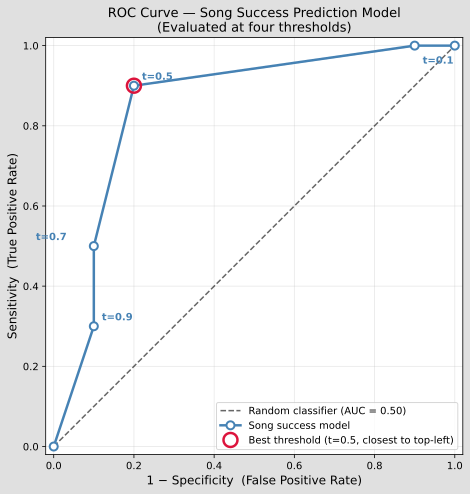

Saved as 'roc_curve.png'. Right-click → Save image, then insert into Word doc.


In [ ]:
# ── CELL 10 — Q2(c): ROC Curve ───────────────────────────────────────────
# PURPOSE : Plots the ROC curve for the four threshold operating points.
# OUTPUT  : A matplotlib plot of the ROC curve, saved as roc_curve.png.
#
# [SCREENSHOT — Q2c]
#   Option A : Right-click the plot and "Save image as..." roc_curve.png
#              Then INSERT the image file directly into the Word doc (best quality)
#   Option B : Screenshot the code cell + the plot together
#   → Either way, insert into the Word doc under:
#     "Part (c) — ROC Curve and Interpretation"
#     (where it says "[Screenshot of ROC curve plot to be inserted here]")

# ROC points: (FPR, TPR) = (1-Specificity, Sensitivity)
# Plus (0,0) origin anchor
fpr_pts = [0.00, 0.10, 0.10, 0.20, 0.90, 1.0]
tpr_pts = [0.00, 0.30, 0.50, 0.90, 1.00, 1.0]
thresh_labels = ['', 't=0.9', 't=0.7', 't=0.5', 't=0.1', '']

fig, ax = plt.subplots(figsize=(7, 7))

# Random classifier diagonal
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random classifier (AUC = 0.50)')

# ROC curve
ax.plot(fpr_pts, tpr_pts, 'o-', color='steelblue', lw=2.5, ms=8,
        markerfacecolor='white', markeredgewidth=2, label='Song success model')

# Label each threshold point
label_offsets = {'t=0.1': (8, -18), 't=0.5': (8, 6), 't=0.7': (-58, 6), 't=0.9': (8, 6)}
for i, lbl in enumerate(thresh_labels):
    if lbl:
        ox, oy = label_offsets.get(lbl, (8, 6))
        ax.annotate(lbl, (fpr_pts[i], tpr_pts[i]),
                    textcoords='offset points', xytext=(ox, oy),
                    fontsize=10, color='steelblue', fontweight='bold')

# Highlight best threshold (t=0.5)
ax.plot(0.20, 0.90, 'o', color='crimson', ms=14, zorder=5,
        markerfacecolor='none', markeredgewidth=2.5,
        label='Best threshold (t=0.5, closest to top-left)')

ax.set_xlabel('1 − Specificity  (False Positive Rate)', fontsize=12)
ax.set_ylabel('Sensitivity  (True Positive Rate)', fontsize=12)
ax.set_title('ROC Curve — Song Success Prediction Model\n(Evaluated at four thresholds)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'roc_curve.png'. Right-click → Save image, then insert into Word doc.")

---
## Question 3 — Risk, Decision Theory and Emergent Behaviour

In [ ]:
# ── CELL 11 — Q3(a): Fatigue Risk Analysis ───────────────────────────────
# PURPOSE : Calculates absolute risk increase, relative risk, and stratified
#           analysis by shift type for the screen exposure / fatigue dataset.
# OUTPUT  : Risk statistics — overall (crude) and stratified by Day/Night shift.
#
# [SCREENSHOT — Q3a (covers sub-parts i, ii, iii)]
#   Screenshot 1 : this code cell
#   Screenshot 2 : the full printed output
#   → Insert into the Word doc under:
#     "Part (a) — Screen Exposure, Shift Type, and Fatigue Risk"
#     Place the screenshot below the summary table already in the doc,
#     to show how the values for sub-parts (i), (ii), and (iii) were calculated.

df_f = pd.read_csv('shift_screen_fatigue_1200.csv')
print(f"Dataset loaded: {df_f.shape[0]} rows")
print(df_f.groupby(['shift','screen_high'])['fatigue'].agg(['sum','count']).rename(
    columns={'sum':'Fatigue_n','count':'Total'}))
print()

low_e  = df_f[df_f['screen_high'] == 0]
high_e = df_f[df_f['screen_high'] == 1]
p_low  = low_e['fatigue'].mean()
p_high = high_e['fatigue'].mean()

print("=" * 55)
print("PART (i) & (ii) — OVERALL (CRUDE) ANALYSIS")
print("=" * 55)
print(f"P(Fatigue | Low screen)  = {low_e.fatigue.sum()}/{len(low_e)}  = {p_low:.4f}  ({p_low*100:.1f}%)")
print(f"P(Fatigue | High screen) = {high_e.fatigue.sum()}/{len(high_e)} = {p_high:.4f}  ({p_high*100:.1f}%)")
print()
print(f"(i)  Absolute Risk Increase (ARR) = {p_high - p_low:.4f}  ({(p_high-p_low)*100:.0f} percentage points)")
print(f"(ii) Relative Risk (RR)           = {p_high/p_low:.4f}  i.e. a {(p_high/p_low - 1)*100:.0f}% relative increase")
print()

print("=" * 55)
print("PART (iii) — STRATIFIED BY SHIFT TYPE")
print("=" * 55)
for shift in ['Day', 'Night']:
    s  = df_f[df_f['shift'] == shift]
    sl = s[s['screen_high'] == 0]
    sh = s[s['screen_high'] == 1]
    pl, ph = sl['fatigue'].mean(), sh['fatigue'].mean()
    print(f"\n{shift} Shift  (n={len(s)}, {len(sl)} low / {len(sh)} high screen):")
    print(f"   P(Fatigue | Low screen)  = {sl.fatigue.sum()}/{len(sl)} = {pl:.4f}  ({pl*100:.1f}%)")
    print(f"   P(Fatigue | High screen) = {sh.fatigue.sum()}/{len(sh)} = {ph:.4f}  ({ph*100:.1f}%)")
    print(f"   ARR = {ph-pl:.4f}  |  RR = {ph/pl:.3f}")

print()
print("=" * 55)
print("CONFOUNDING ASSESSMENT")
print("=" * 55)
for shift in ['Day', 'Night']:
    s = df_f[df_f['shift'] == shift]
    rate = (s['screen_high'] == 1).mean()
    print(f"  Screen exposure rate in {shift} shift: {rate:.2f}")
print()
print("Screen exposure is EQUALLY distributed across shift types (50% each).")
print("→ Shift is NOT associated with exposure → NOT a classical confounder.")
print("→ However, RR differs greatly by shift (Day≈1.17 vs Night≈1.56).")
print("→ Shift type is an EFFECT MODIFIER (interaction variable).")

Dataset loaded: 1200 rows
                   Fatigue_n  Total
shift screen_high                  
Day   0                   60    350
      1                   70    350
Night 0                   90    250
      1                  140    250

PART (i) & (ii) — OVERALL (CRUDE) ANALYSIS
P(Fatigue | Low screen)  = 150/600  = 0.2500  (25.0%)
P(Fatigue | High screen) = 210/600 = 0.3500  (35.0%)

(i)  Absolute Risk Increase (ARR) = 0.1000  (10 percentage points)
(ii) Relative Risk (RR)           = 1.4000  i.e. a 40% relative increase

PART (iii) — STRATIFIED BY SHIFT TYPE

Day Shift  (n=700, 350 low / 350 high screen):
   P(Fatigue | Low screen)  = 60/350 = 0.1714  (17.1%)
   P(Fatigue | High screen) = 70/350 = 0.2000  (20.0%)
   ARR = 0.0286  |  RR = 1.167

Night Shift  (n=500, 250 low / 250 high screen):
   P(Fatigue | Low screen)  = 90/250 = 0.3600  (36.0%)
   P(Fatigue | High screen) = 140/250 = 0.5600  (56.0%)
   ARR = 0.2000  |  RR = 1.556

CONFOUNDING ASSESSMENT
  Screen exposure rate

Oliver's Mystery Prize Box — Expected Utility

(i) E[play] = (1/3 × £15) + (2/3 × £0) − £4
           = £5.00 + £0.00 − £4
           = £1.00
    E[not play] = £0.00
    → Total expected utility of playing = £1.00  (positive, so Oliver should PLAY)

(ii) EU[play] with £6 thrill = £1.00 + £6 = £7.00
     EU[not play] = £0
     → Oliver should DEFINITELY play (£7.00 >> £0)

(iii) Building PyAgrum Influence Diagram...
---------------------------------------------

Optimal decision: 
  Decision         |
DontPlay |Play     |
---------|---------|
 0.0000  | 1.0000  |

Maximum Expected Utility (MEU): {'mean': 1.0, 'variance': 49.99999999999999}



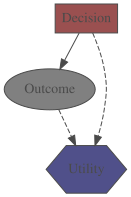

In [ ]:
# ── CELL 12 — Q3(b): Oliver's Mystery Prize Box ─────────────────────────
# PURPOSE : (i)  Calculates expected utility of playing
#           (ii) Re-checks with thrill utility included
#           (iii) Builds and solves a PyAgrum influence diagram
# OUTPUT  : Printed expected utility values + influence diagram.
#
# [SCREENSHOT — Q3b parts i and ii]
#   Screenshot 1 : the printed expected utility output (first block)
#   → Insert into the Word doc under:
#     "Part (b) — Oliver's Mystery Prize Box", sub-parts (i) and (ii)
#
# [SCREENSHOT — Q3b part iii]
#   Screenshot 2 : this code cell
#   Screenshot 3 : the influence diagram displayed below
#   → Insert BOTH into the Word doc under sub-part (iii)
#     (where it says "[Screenshot of code and the influence diagram to be inserted here]")

print("Oliver's Mystery Prize Box — Expected Utility")
print("=" * 55)
p_win, p_lose = 1/3, 2/3
prize, fee    = 15, 4

# (i) Expected monetary value
emv = (p_win * prize) + (p_lose * 0) - fee
print(f"\n(i) E[play] = (1/3 × £{prize}) + (2/3 × £0) − £{fee}")
print(f"           = £{p_win*prize:.2f} + £0.00 − £{fee}")
print(f"           = £{emv:.2f}")
print(f"    E[not play] = £0.00")
print(f"    → Total expected utility of playing = £{emv:.2f}  (positive, so Oliver should PLAY)")

# (ii) With thrill
thrill = 6
eu_play = emv + thrill
print(f"\n(ii) EU[play] with £{thrill} thrill = £{emv:.2f} + £{thrill} = £{eu_play:.2f}")
print(f"     EU[not play] = £0")
print(f"     → Oliver should DEFINITELY play (£{eu_play:.2f} >> £0)")
print()

# (iii) PyAgrum Influence Diagram
print("(iii) Building PyAgrum Influence Diagram...")
print("-" * 45)

diag = gum.InfluenceDiagram()

# Decision node
diag.addDecisionNode(gum.LabelizedVariable('Decision', 'Play the game?', ['DontPlay', 'Play']))
# Chance node — outcome of opening the box
diag.addChanceNode(gum.LabelizedVariable('Outcome', 'Prize found?', ['NoPrize', 'Prize']))
# Utility node — net monetary gain
diag.addUtilityNode(gum.LabelizedVariable('Utility', 'Net gain (£)', 1))

# Arcs
diag.addArc('Decision', 'Outcome')
diag.addArc('Decision', 'Utility')
diag.addArc('Outcome',  'Utility')

# CPT for Outcome
diag.cpt('Outcome')[{'Decision': 'DontPlay'}] = [1.0, 0.0]    # no box opened
diag.cpt('Outcome')[{'Decision': 'Play'}]     = [2/3, 1/3]    # P(Prize) = 1/3

# Utility table — net monetary outcomes
diag.utility('Utility')[{'Decision': 'DontPlay', 'Outcome': 'NoPrize'}] = [0]
diag.utility('Utility')[{'Decision': 'DontPlay', 'Outcome': 'Prize'}]   = [0]
diag.utility('Utility')[{'Decision': 'Play',     'Outcome': 'NoPrize'}] = [-4]   # lose entry fee
diag.utility('Utility')[{'Decision': 'Play',     'Outcome': 'Prize'}]   = [11]   # £15 - £4 = £11

# Solve
ie_id = gum.ShaferShenoyLIMIDInference(diag)
ie_id.makeInference()

print()
print("Optimal decision:", ie_id.optimalDecision('Decision'))
print("Maximum Expected Utility (MEU):", ie_id.MEU())
print()

# Display the influence diagram
gnb.showInfluenceDiagram(diag)